# ACTIVIDAD 2 - REDES RECURRENTES

Integrantes:
* Valentina López Maldonado
* Yerson David Rozo
* Juan Sebastián Peña


**PRIMER PUNTO**
Replicar el proceso de análisis de sentimientos trabajado previamente Implementando los modelos Para el dataset [IMDb: 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews):

   * Una red neuronal recurrente (RNN).
   * Una red LSTM.
   * Una red GRU.


### **Análisis requerido**

Además de la implementación, deben realizar un análisis comparativo detallado donde respondan, como MÍNIMO:

* ¿Qué diferencias observaron entre las aqrquitecturas?
* ¿Qué diferencias encuentran respecto al modelo mlp?
* ¿Cómo cambian los resultados (métricas, estabilidad, comportamiento del entrenamiento)?
* ¿Qué ventajas y desventajas identifican en cada arquitectura?
* ¿Qué decisiones tomaron durante el diseño del modelo y por qué?

 La parte más importante de la actividad es su análisis personal y crítico de cada paso realizado. No se trata solo de que el modelo funcione, sino de que demuestren comprensión del proceso.

### **Entrega**

* El archivo debe ser un notebook (.ipynb).
* Debe nombrarse con el nombre de los integrantes
* Asegúrense de que el notebook esté limpio, ordenado y correctamente documentado.


**SEGUNDO PUNTO**

Investigue las diferentes métricas utilizadas para evaluar la calidad de la generación de texto (coherencia, fluidez, relevancia, entre otras).

## Importación de librerías

Para este proyecto usamos tres librerías base, `gensim` para acceder a modelos de lenguaje preentrenados, `numpy` para operar sobre los vectores resultantes, y `pandas` para organizar esa información en tablas y poder analizarla más fácilmente.

Las siguientes son para visualización de gráficas, para importar la red neuronal MLP, entrenarla y finalmente hacer el reporte de clasificación para el análisis de los resultados.

In [49]:
import gensim.downloader as api  # Librería para cargar modelos de lenguaje preentrenados (Word2Vec)
import matplotlib.pyplot as plt  # Para mostrar las matrices de confusión lado a lado
import numpy as np  # Librería para trabajar con embeddings
import pandas as pd  #Librería para manipulación de datos (DataFrames)
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display  # Para visualizar outputs como tablas y gráficas en el notebook
from sklearn import set_config  # Para configurar la visualización del pipeline
from sklearn.metrics import (
    ConfusionMatrixDisplay,  # Para ver la matriz de confusión del modelo
    accuracy_score,  # Calcular el porcentaje de predicciones correctas
    classification_report,  # Reporte completo: precisión, recall y F1 por clase
    f1_score,  # Métrica que balancea precisión y recall
    precision_score,  # Ver qué tan confiables son las predicciones positivas
    recall_score,  # Ver qué tan bien detecta los casos positivos reales
    roc_auc_score,  # Mide el área bajo la curva ROC 
)
from sklearn.model_selection import train_test_split  # Para dividir el dataset en train y test
from sklearn.neural_network import MLPClassifier  # Para clasificar con la MLP
from sklearn.pipeline import Pipeline  # Para el pipeline de la MLP
from sklearn.preprocessing import StandardScaler  # Normalización de los datos para la MLP


Para representar las palabras como números, cargamos el modelo `word2vec-google-news-300`, el cual usa la arquitectura Skip_Gram, que como fue mencionado en clase, aprende el contexto en base a una palabra central y `fasttext-wiki-news-subwords-300`, el cual usa la arquitectura CBOW (continuous bag of words) la cual aprende una palabra central en base al contexto al rededor de ella.

* **CBOW:** predice la palabra central basándose en las palabras del contexto circundante. El contexto consta de algunas palabras antes y después de la palabra actual (central). [1]

* **Skip-Gram:** predice palabras dentro de un rango determinado antes y después de la palabra actual en la misma oración. [1]

![skip_gram](https://kavita-ganesan.com/wp-content/uploads/skipgram-vs-cbow-continuous-bag-of-words-word2vec-word-representation.png)

El modelo `word2vec-google-news-300` contiene 3 millones de palabras representadas como una lista de 300 números (un vector) [2]
El modelo `fasttext-wiki-news-subwords-300` contiene 1 millon de palabras representadas como una lista de 300 números (un vector) [3]

In [50]:
modelo_skipgram = api.load("word2vec-google-news-300")
modelo_cbow = api.load("fasttext-wiki-news-subwords-300")

In [51]:
skipgram_embedding_size = modelo_skipgram.vector_size
cbow_embedding_size = modelo_cbow.vector_size
print(f"Skip-gram embedding size: {skipgram_embedding_size}")
print(f"CBOW embedding size: {cbow_embedding_size}")

Skip-gram embedding size: 300
CBOW embedding size: 300


In [52]:
modelo_cbow['night']

array([-2.3558e-02, -7.4858e-02,  6.8382e-03, -9.9507e-03,  3.6644e-02,
       -3.9823e-02,  9.1564e-02, -9.8252e-02,  1.0796e-01,  1.0447e-02,
       -1.0639e-02, -2.4376e-02,  3.0998e-02,  1.2258e-02, -1.1177e-03,
       -3.3580e-02,  1.2741e-01, -6.4947e-02,  3.0103e-02,  2.7520e-02,
        6.8571e-02, -2.5042e-02, -7.7567e-02, -8.0912e-03,  3.1584e-02,
        5.2285e-02,  2.6677e-02, -1.9917e-02, -3.1714e-02, -5.2434e-03,
        1.7798e-02,  3.7835e-03, -2.5702e-02, -1.7277e-01,  2.0223e-02,
       -9.7335e-03, -1.5111e-02,  6.1259e-02, -6.1486e-02,  8.5875e-03,
       -2.2680e-02, -6.5125e-02, -5.2327e-02,  4.4110e-02,  1.1889e-02,
        7.9052e-02,  6.0501e-02, -7.2342e-03, -7.9884e-02,  7.0792e-02,
        6.7738e-03,  8.3687e-02,  2.2378e-02, -1.0430e-02, -1.0534e-01,
        5.8665e-03, -2.9618e-03, -5.9915e-02, -7.2752e-02, -4.6762e-02,
       -5.0482e-02, -1.3880e-02,  1.7023e-01, -3.8989e-02, -4.0625e-02,
        6.9720e-02, -4.6445e-02, -1.3132e-02, -3.9110e-02,  1.85

In [53]:
modelo_skipgram['night']

array([ 0.01574707,  0.07666016, -0.03222656,  0.0201416 ,  0.01525879,
       -0.05297852, -0.01446533, -0.1953125 ,  0.05883789,  0.125     ,
        0.0480957 , -0.10107422,  0.04199219,  0.03930664,  0.10302734,
        0.03295898, -0.08300781,  0.1328125 ,  0.24609375,  0.11035156,
        0.12695312,  0.04956055, -0.01116943, -0.14453125, -0.15429688,
        0.06005859,  0.13867188,  0.15722656,  0.07861328,  0.01757812,
       -0.01904297, -0.05004883,  0.16796875, -0.02722168,  0.01879883,
        0.08203125,  0.09033203, -0.02575684, -0.09228516,  0.01904297,
       -0.16015625, -0.14160156,  0.40039062,  0.01794434,  0.0534668 ,
        0.07666016, -0.125     , -0.03466797,  0.21582031,  0.15332031,
        0.1640625 ,  0.2421875 , -0.01068115,  0.0378418 ,  0.15917969,
       -0.23828125,  0.12255859, -0.04125977,  0.04736328, -0.05102539,
       -0.15039062,  0.29101562, -0.0177002 , -0.04174805, -0.0246582 ,
        0.09033203,  0.04125977, -0.01397705,  0.11132812,  0.03

Aquí se carga el dataset de reseñas de películas de IMDB, que contiene reseñas escritas por usuarios junto con la etiqueta de sentimiento (positivo o negativo), y para poder leer el texto completo de cada reseña sin que pandas lo cortara, se configuró la opción `display.max_colwidth` en `None`. Finalmente, se usó `df.head()` para revisar las primeras filas y confirmar que los datos se cargaron correctamente.

In [54]:
import kagglehub
import os

In [55]:
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

In [56]:
csv_path = os.path.join(path, "IMDB Dataset.csv")

In [57]:
df = pd.read_csv(csv_path)

# Permite ver el contenido completo de cada celda sin que se corte el texto

pd.set_option('display.max_colwidth',None) 
# Muestra las primeras filas del DataFrame (review y sentiment)
df.head() 

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her ""sexy"" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than ""Devil Wears Prada"" and more interesting than ""Superman"" a great comedy to go see with friends.",positive
3,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zom

Antes de poder usar el modelo de embeddings, el texto necesita ser preprocesado y para esto se requiere de una tokenización, la cual limpia y divide cada reseña en una lista de palabras individuales. 

### Tokenización

Primero se pasa todo el texto a minúsculas para evitar que la misma palabra la tome como dos solo por esa diferencia, luego se eliminan las etiquetas HTML como `<br />` que vienen dentro del texto del dataset, así como se puede observar en la visualización de la celda anterior. Después se quita la puntuación, excepto el apóstrofe porque es parte de palabras comunes en inglés como "don't". Finalmente, cada reseña queda como una lista de palabras para asi ser transformadas en vectores.

### Word2Vec

Después de tokenizar el texto, se debe convertir cada palabra en su representación vectorial usando el modelo `Word2Vec`. Así, para cada reseña, se recorre su lista de tokens y se busca cada palabra dentro del vocabulario del modelo, entonces, si la palabra existe, se obtiene su vector de 300 dimensiones y si no existe, se ignora. Esto nos parece importante porque el modelo no conoce todas las palabras, por lo que al final, cada reseña queda representada como una lista de vectores, uno por cada palabra que el modelo reconoce.


In [58]:
# Tokenizacion basica: minusculas, limpieza de saltos HTML y separacion por palabras.
df["tokens"] = (
    df["review"]
    .str.lower() #minusculas
    .str.replace(r"<br\s*/?>", " ", regex=True) #quitar saltos de linea
    .str.replace(r"[^a-z0-9']+", " ", regex=True) #quitar puntuacion menos el apostrofe
    .str.split() #separar como array
 )

df[["review", "tokens"]].head() # Mostrar comparación entre la reseña original y sus tokens

,review,tokens
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.","[one, of, the, other, reviewers, has, mentioned, that, after, watching, just, 1, oz, episode, you'll, be, hooked, they, are, right, as, this, is, exactly, what, happened, with, me, the, first, thing, that, struck, me, about, oz, was, its, brutality, and, unflinching, scenes, of, violence, which, set, in, right, from, the, word, go, trust, me, this, is, not, a, show, for, the, faint, hearted, or, timid, this, show, pulls, no, punches, with, regards, to, drugs, sex, or, violence, its, is, hardcore, in, the, classic, use, of, the, word, it, is, called, oz, as, that, is, the, nickname, given, to, the, oswald, ...]"
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.","[a, wonderful, little, production, the, filming, technique, is, very, unassuming, very, old, time, bbc, fashion, and, gives, a, comforting, and, sometimes, discomforting, sense, of, realism, to, the, entire, piece, the, actors, are, extremely, well, chosen, michael, sheen, not, only, has, got, all, the, polari, but, he, has, all, the, voices, down, pat, too, you, can, truly, see, the, seamless, editing, guided, by, the, references, to, williams', diary, entries, not, only, is, it, well, worth, the, watching, but, it, is, a, terrificly, written, and, performed, piece, a, masterful, produ

In [59]:
# Obtener el embedding de cada token que exista en el vocabulario del modelo.
df["skipgram_embeddings"] = df["tokens"].apply(
    lambda tokens: [modelo_skipgram[token] for token in tokens if token in modelo_skipgram]
)

df["cbow_embeddings"] = df["tokens"].apply(
    lambda tokens: [modelo_cbow[token] for token in tokens if token in modelo_cbow]
)

### Validación del proceso de tokenización y embedding

Aqui se hace una vista comparativa que muestra el total de palabras que tenia originalmente `n_tokens`, y cuantas de esas palabras se encontraron en el voabulario del modelo `n_embeddings`. Así podemos ver cuantas palabras fueron ignoradas por no estar en el modelo

In [60]:
# Vista compacta para comprobar columnas.
df.assign(
    review_preview=df["review"].apply(lambda x: " ".join(x.split()[:10])),
    n_tokens=df["tokens"].apply(len),
    n_skipgram_embeddings=df["skipgram_embeddings"].apply(len),
    n_cbow_embeddings=df["cbow_embeddings"].apply(len),
    skipgram_tokens_preview=df["skipgram_embeddings"].apply(lambda tokens: tokens[0][:10]),
    cbow_tokens_preview=df["cbow_embeddings"].apply(lambda tokens: tokens[0][:10])

)[ ["review_preview", 
    "n_tokens", 
    "n_skipgram_embeddings",
    "n_cbow_embeddings",
    "skipgram_tokens_preview",
    "cbow_tokens_preview"] ].head()

#quiero mostrar solo 10 indices del primer token de cada review


,review_preview,n_tokens,n_skipgram_embeddings,n_cbow_embeddings,skipgram_tokens_preview,cbow_tokens_preview
0,One of the other reviewers has mentioned that after watching,308,283,301,"[0.045654297, -0.14550781, 0.15625, 0.16601562, 0.10986328, 0.007507324, 0.07373047, -0.03100586, 0.15722656, 0.099609375]","[0.019569, 0.0051348, 0.024567, -0.0037714, -0.052806, -0.010756, 0.01668, -0.17925, -0.074614, -0.016145]"
1,A wonderful little production. <br /><br />The filming technique is,158,134,152,"[0.0062561035, 0.01928711, -0.08984375, 0.14257812, 0.10205078, -0.13574219, 0.13867188, -0.071777344, -0.12597656, 0.16308594]","[-0.0079206, -0.095293, 0.031266, 0.017734, -0.20123, -0.0056356, -0.017696, 0.20456, 0.051267, 0.024726]"
2,I thought this was a wonderful way to spend time,165,143,161,"[-0.22558594, -0.01953125, 0.09082031, 0.23730469, -0.029296875, 0.09326172, -0.05883789, -0.041015625, 0.052246094, 0.020019531]","[-0.060418, 0.069955, 0.053173, 0.052922, 0.053978, 0.13479, 0.052614, 0.3548, -0.17565, -0.09902]"
3,Basically there's a family where a little boy (Jake) thinks,132,112,129,"[0.18261719, -0.08935547, 0.048828125, 0.24902344, -0.09814453, 0.052001953, 0.060302734, -0.23535156, -0.02758789, 0.025512695]","[0.037373, 0.030506, -0.0062058, 0.011153, 0.00066242, -0.057258, 0.015729, -0.081667, -0.025708, -0.01364]"
4,"Petter Mattei's ""Love in the Time of Money"" is a",225,192,218,"[0.103027344, -0.15234375, 0.025878906, 0.16503906, -0.16503906, 0.06689453, 0.29296875, -0.26367188, -0.140625, 0.20117188]","[-0.0105, -0.0053143, 0.0080346, 0.00036603, -0.0029899, -0.0058693, 0.013124, -0.08776, 0.0021014, 0.011181]"


### Modelo con Redes Neuronales Recurrentes

Debido a que las  redes recurrentes necesitan una longitud fija (o manejar padding), la nueva estructura de entrada ya no es $(N, 300)$, ahora será un Tensor 3D: $(N, \text{max\_sequence\_length}, 300)$. Para este modelo principalmente se necesita definir una longitud máxima (max_len). Si una reseña tiene más palabras, la cortamos; si tiene menos, la rellenamos con vectores de ceros. Como no estamos usando índices enteros (mapeo), no se puede usar pad_sequences estándar de Keras fácilmente. Necesitamos una función que rellene con un vector de ceros [0.0] * 300.

In [72]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

In [73]:
MAX_LEN    = 200
BATCH_SIZE = 32
HIDDEN_SIZE = 128
EPOCHS     = 20       
LR         = 1e-3
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Se pasan los labels del dataset que vienen en formato str directamente para poderlos trabajar en el modelo a continuación.

In [74]:
df["label"] = (df["sentiment"] == "positive").astype(int)

Para poder alimentar la red neuronal recurrente con texto, es necesario transformar cada reseña desde su representación como lista de palabras hacia una representación numérica que el modelo pueda procesar. 

In [75]:
def embeddings_to_tensor(embedding_list, max_len=MAX_LEN):
    vecs = embedding_list[:max_len]
    if not vecs:
        vecs = [np.zeros(300, dtype=np.float32)]
    return torch.tensor(np.array(vecs, dtype=np.float32))

Se define una clase IMDBDataset que hereda de Dataset de PyTorch, estructura estándar que permite al DataLoader gestionar los datos durante el entrenamiento. En el constructor se precomputan y almacenan en memoria todos los tensores de embeddings junto con sus etiquetas binarias, evitando recalcularlos en cada época. Los métodos __len__ y __getitem__ son obligatorios en esta interfaz: el primero informa al DataLoader el tamaño total del dataset y el segundo permite recuperar cualquier muestra por índice, devolviendo el par tensor de embeddings y etiqueta que el DataLoader usará para construir cada batch.

In [76]:
class IMDBDataset(Dataset):
    def __init__(self, embedding_lists, labels):
        self.samples = [embeddings_to_tensor(embs) for embs in embedding_lists]
        self.labels  = torch.tensor(labels.values, dtype=torch.float32)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.samples[idx], self.labels[idx]

Dado que cada reseña tiene una longitud distinta, las secuencias dentro de un mismo batch no pueden apilarse directamente en un tensor rectangular. collate_fn resuelve esto recibiendo la lista de muestras que el DataLoader agrupó y aplicando padding, es decir, rellenando con ceros las secuencias más cortas hasta igualar la longitud de la más larga del batch. Adicionalmente se guardan las longitudes reales de cada secuencia antes del padding, información que posteriormente utiliza pack_padded_sequence dentro del modelo para que la RNN ignore los ceros añadidos y procese únicamente los tokens originales, evitando que el padding distorsione el estado oculto final y por tanto las predicciones.

In [77]:
def collate_fn(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs])
    padded  = pad_sequence(seqs, batch_first=True)
    return padded, torch.stack(list(labels)), lengths


In [78]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)

Se implementa Early Stopping como una clase que monitorea la pérdida de validación época a época para detener el entrenamiento cuando el modelo deja de mejorar, evitando así el sobreajuste y el desperdicio de cómputo. En cada época el método step compara la pérdida actual contra la mejor registrada: si mejora por encima del umbral min_delta, reinicia el contador y guarda una copia de los pesos del modelo en CPU para no consumir memoria de la GPU; si no mejora, incrementa el contador y detiene el entrenamiento al alcanzar el límite de patience épocas consecutivas sin progreso. Al finalizar, el método restore recarga los pesos de la época con menor pérdida de validación, garantizando que el modelo entregado corresponde a su mejor estado durante el entrenamiento y no al último antes de detenerse.

In [79]:
class EarlyStopping:
    """
    Detiene el entrenamiento si val_loss no mejora en `patience` épocas.
    Guarda los mejores pesos en memoria.
    """
    def __init__(self, patience=3, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = float("inf")
        self.counter    = 0
        self.best_weights = None
        self.stopped    = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss    = val_loss
            self.counter      = 0
            # Guarda copia profunda de los pesos en CPU (no ocupa VRAM)
            self.best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped = True

    def restore(self, model):
        """Restaura los pesos de la mejor época."""
        if self.best_weights:
            model.load_state_dict(self.best_weights)

La red recibe secuencias de embeddings de 300 dimensiones y las procesa a través de una capa RNN con 128 unidades ocultas y función de activación tangente hiperbólica. En el método forward, la secuencia se empaqueta con pack_padded_sequence usando las longitudes reales de cada reseña para que la RNN ignore los tokens de padding durante el cómputo, extrayendo únicamente el estado oculto final h_n que condensa la información de toda la secuencia. Este vector pasa por una capa de Dropout con probabilidad 0.3 para reducir el sobreajuste, y finalmente por una capa lineal que lo proyecta a un único valor escalar por reseña, el cual representa el logit de la clasificación binaria positivo/negativo antes de aplicar la función sigmoide.

In [80]:
class SentimentRNN(nn.Module):
    def __init__(self, input_size=300, hidden_size=HIDDEN_SIZE, dropout=0.3):
        super().__init__()
        self.rnn  = nn.RNN(input_size, hidden_size, num_layers=1,
                           batch_first=True, nonlinearity="tanh")
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x, lengths):
        packed   = pack_padded_sequence(x, lengths.cpu(), batch_first=True,
                                        enforce_sorted=False)
        _, h_n   = self.rnn(packed)
        h        = h_n.squeeze(0)
        return self.fc(self.drop(h)).squeeze(1)


Se define una función genérica de entrenamiento que recibe cualquier modelo de embeddings, lo que permite entrenar con Skip-gram y CBOW sin duplicar código. En cada época el ciclo de entrenamiento propaga los batches hacia adelante, calcula la pérdida con BCEWithLogitsLoss que combina sigmoide y entropía cruzada binaria en una sola operación numéricamente estable, y actualiza los pesos mediante el optimizador Adam con regularización L2. El gradiente se recorta a norma máxima de 1.0 antes de cada actualización para prevenir el problema de gradientes explosivos característico de las RNN simples. Tras cada época se evalúa el modelo sobre el conjunto de validación sin calcular gradientes, y tanto la pérdida como el accuracy se registran en el historial. El scheduler ReduceLROnPlateau reduce la tasa de aprendizaje a la mitad si la pérdida de validación no mejora en una época, mientras que el Early Stopping detiene el entrenamiento completo si no hay mejora en tres épocas consecutivas y restaura los pesos óptimos al finalizar.

In [81]:
def train_model(embedding_col, model_name, patience=3):
    print(f"\n{'='*55}")
    print(f"  Entrenando con: {model_name}")
    print(f"{'='*55}")

    # Datasets y loaders
    train_ds = IMDBDataset(train_df[embedding_col].tolist(), train_df["label"])
    test_ds  = IMDBDataset(test_df[embedding_col].tolist(),  test_df["label"])
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              collate_fn=collate_fn, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              collate_fn=collate_fn, num_workers=0, pin_memory=True)

    # Modelo, pérdida, optimizador
    model     = SentimentRNN().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, factor=0.5)
    es        = EarlyStopping(patience=patience)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, EPOCHS + 1):
        # — Train —
        model.train()
        total_loss = 0
        for X, y, lengths in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X, lengths), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        avg_train = total_loss / len(train_loader)

        # — Validación —
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for X, y, lengths in test_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                logits = model(X, lengths)
                val_loss += criterion(logits, y).item()
                preds     = (torch.sigmoid(logits) >= 0.5).long()
                correct  += (preds == y.long()).sum().item()
                total    += y.size(0)

        avg_val  = val_loss / len(test_loader)
        val_acc  = correct / total
        scheduler.step(avg_val)
        es.step(avg_val, model)

        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        history["val_acc"].append(val_acc)

        stop_mark = " ← mejor" if es.counter == 0 else f" (sin mejora: {es.counter}/{patience})"
        print(f"Epoch {epoch:>2}/{EPOCHS} | "
              f"Train: {avg_train:.4f} | Val: {avg_val:.4f} | "
              f"Acc: {val_acc:.4f}{stop_mark}")

        if es.stopped:
            print(f"\n⏹ Early stopping en época {epoch}. "
                  f"Mejor val_loss: {es.best_loss:.4f}")
            break

    es.restore(model)
    print(f"✔ Pesos restaurados a la mejor época.")
    return model, history, test_loader

Se hace el entrenamiento del modelo utilizando ambos Word2Vec, Skip-Gram y CBOW, respectivamente.

In [82]:
model_sg, history_sg, loader_sg = train_model("skipgram_embeddings", "Skip-gram (word2vec-google-news-300)")


  Entrenando con: Skip-gram (word2vec-google-news-300)


c:\Users\desar\OneDrive\Escritorio\ai-notebooks\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  1/20 | Train: 0.5699 | Val: 0.5240 | Acc: 0.7618 ← mejor
Epoch  2/20 | Train: 0.5129 | Val: 0.6105 | Acc: 0.7276 (sin mejora: 1/3)
Epoch  3/20 | Train: 0.5224 | Val: 0.5250 | Acc: 0.7795 (sin mejora: 2/3)
Epoch  4/20 | Train: 0.4676 | Val: 0.4309 | Acc: 0.8195 ← mejor
Epoch  5/20 | Train: 0.4553 | Val: 0.4521 | Acc: 0.8157 (sin mejora: 1/3)
Epoch  6/20 | Train: 0.4567 | Val: 0.4362 | Acc: 0.8084 (sin mejora: 2/3)
Epoch  7/20 | Train: 0.4121 | Val: 0.4231 | Acc: 0.8234 ← mejor
Epoch  8/20 | Train: 0.3996 | Val: 0.3874 | Acc: 0.8335 ← mejor
Epoch  9/20 | Train: 0.4016 | Val: 0.3994 | Acc: 0.8321 (sin mejora: 1/3)
Epoch 10/20 | Train: 0.3949 | Val: 0.3924 | Acc: 0.8316 (sin mejora: 2/3)
Epoch 11/20 | Train: 0.3865 | Val: 0.4496 | Acc: 0.8271 (sin mejora: 3/3)

⏹ Early stopping en época 11. Mejor val_loss: 0.3874
✔ Pesos restaurados a la mejor época.


In [83]:
model_cbow, history_cbow, loader_cbow = train_model("cbow_embeddings", "CBOW (fasttext-wiki-news-subwords-300)")


  Entrenando con: CBOW (fasttext-wiki-news-subwords-300)
Epoch  1/20 | Train: 0.5988 | Val: 0.5726 | Acc: 0.7101 ← mejor
Epoch  2/20 | Train: 0.5244 | Val: 0.4991 | Acc: 0.7756 ← mejor
Epoch  3/20 | Train: 0.5084 | Val: 0.5733 | Acc: 0.7111 (sin mejora: 1/3)
Epoch  4/20 | Train: 0.5093 | Val: 0.4723 | Acc: 0.7977 ← mejor
Epoch  5/20 | Train: 0.6292 | Val: 0.6226 | Acc: 0.6909 (sin mejora: 1/3)
Epoch  6/20 | Train: 0.6364 | Val: 0.6951 | Acc: 0.5916 (sin mejora: 2/3)
Epoch  7/20 | Train: 0.5762 | Val: 0.5482 | Acc: 0.7462 (sin mejora: 3/3)

⏹ Early stopping en época 7. Mejor val_loss: 0.4723
✔ Pesos restaurados a la mejor época.


Se evalúan ambos modelos entrenados sobre el conjunto de prueba en modo inferencia, desactivando el cálculo de gradientes para reducir el consumo de memoria. Por cada batch se obtienen las probabilidades continuas aplicando la función sigmoide sobre los logits, y las predicciones binarias umbralando dichas probabilidades en 0.5. Al recorrer todo el loader se acumulan etiquetas reales, predicciones y probabilidades, con las cuales se genera el reporte de clasificación que detalla precisión, recall y F1 por clase, complementado con el ROC-AUC que mide la capacidad discriminativa del modelo independientemente del umbral elegido. Este proceso se ejecuta de forma idéntica para Skip-gram y CBOW, permitiendo comparar ambos modelos bajo exactamente las mismas condiciones de evaluación.

In [84]:
def evaluate_model(model, loader, name):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for X, y, lengths in loader:
            X      = X.to(DEVICE)
            probs  = torch.sigmoid(model(X, lengths)).cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(y.numpy().astype(int))

    print(f"\n{'─'*45}")
    print(f"  Resultados — {name}")
    print(f"{'─'*45}")
    print(classification_report(all_labels, all_preds,
                                 target_names=["Negative", "Positive"]))
    print(f"ROC-AUC : {roc_auc_score(all_labels, all_probs):.4f}")
    return all_labels, all_preds, all_probs

labels_sg,   preds_sg,   probs_sg   = evaluate_model(model_sg,   loader_sg,   "Skip-gram")
labels_cbow, preds_cbow, probs_cbow = evaluate_model(model_cbow, loader_cbow, "CBOW")


─────────────────────────────────────────────
  Resultados — Skip-gram
─────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.82      0.86      0.84      5000
    Positive       0.85      0.81      0.83      5000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000

ROC-AUC : 0.9083


c:\Users\desar\OneDrive\Escritorio\ai-notebooks\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



─────────────────────────────────────────────
  Resultados — CBOW
─────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.81      0.77      0.79      5000
    Positive       0.78      0.82      0.80      5000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000

ROC-AUC : 0.8571


El modelo entrenado con embeddings Skip-gram (word2vec-google-news-300) demostró un desempeño superior en todas las métricas evaluadas. Alcanzó una accuracy del 83% sobre el conjunto de prueba, con un F1-score balanceado de 0.84 para reseñas negativas y 0.83 para positivas, lo que indica que el modelo clasifica ambas clases con equilibrio similar sin sesgo hacia ninguna. El ROC-AUC de 0.9083 es particularmente destacable, pues refleja que el modelo tiene una capacidad discriminativa muy alta independientemente del umbral de decisión. El entrenamiento fue estable: la pérdida de validación descendió consistentemente hasta la época 8 donde se registró el mejor valor de 0.3874, y el Early Stopping detuvo correctamente el proceso en la época 11 al detectar tres épocas consecutivas sin mejora, restaurando los pesos óptimos.

El modelo con embeddings CBOW (fasttext-wiki-news-subwords-300) mostró un comportamiento notablemente menos estable. Si bien alcanzó una accuracy del 80% y un ROC-AUC de 0.8571, valores aceptables para una RNN simple, su curva de pérdida revela un problema de inestabilidad en el entrenamiento: tras una mejora inicial en las épocas 2 y 4, la pérdida tanto de entrenamiento como de validación aumentó drásticamente en las épocas 5 y 6, comportamiento que sugiere que la tasa de aprendizaje era demasiado alta para la geometría del espacio de embeddings de FastText. El Early Stopping intervino en la época 7 recuperando los pesos de la época 4, pero el daño al proceso de optimización ya era visible. La matriz de confusión refleja además una mayor cantidad de falsos negativos (1148) en comparación con Skip-gram (723), lo que indica que CBOW tuvo más dificultad para identificar correctamente las reseñas negativas.

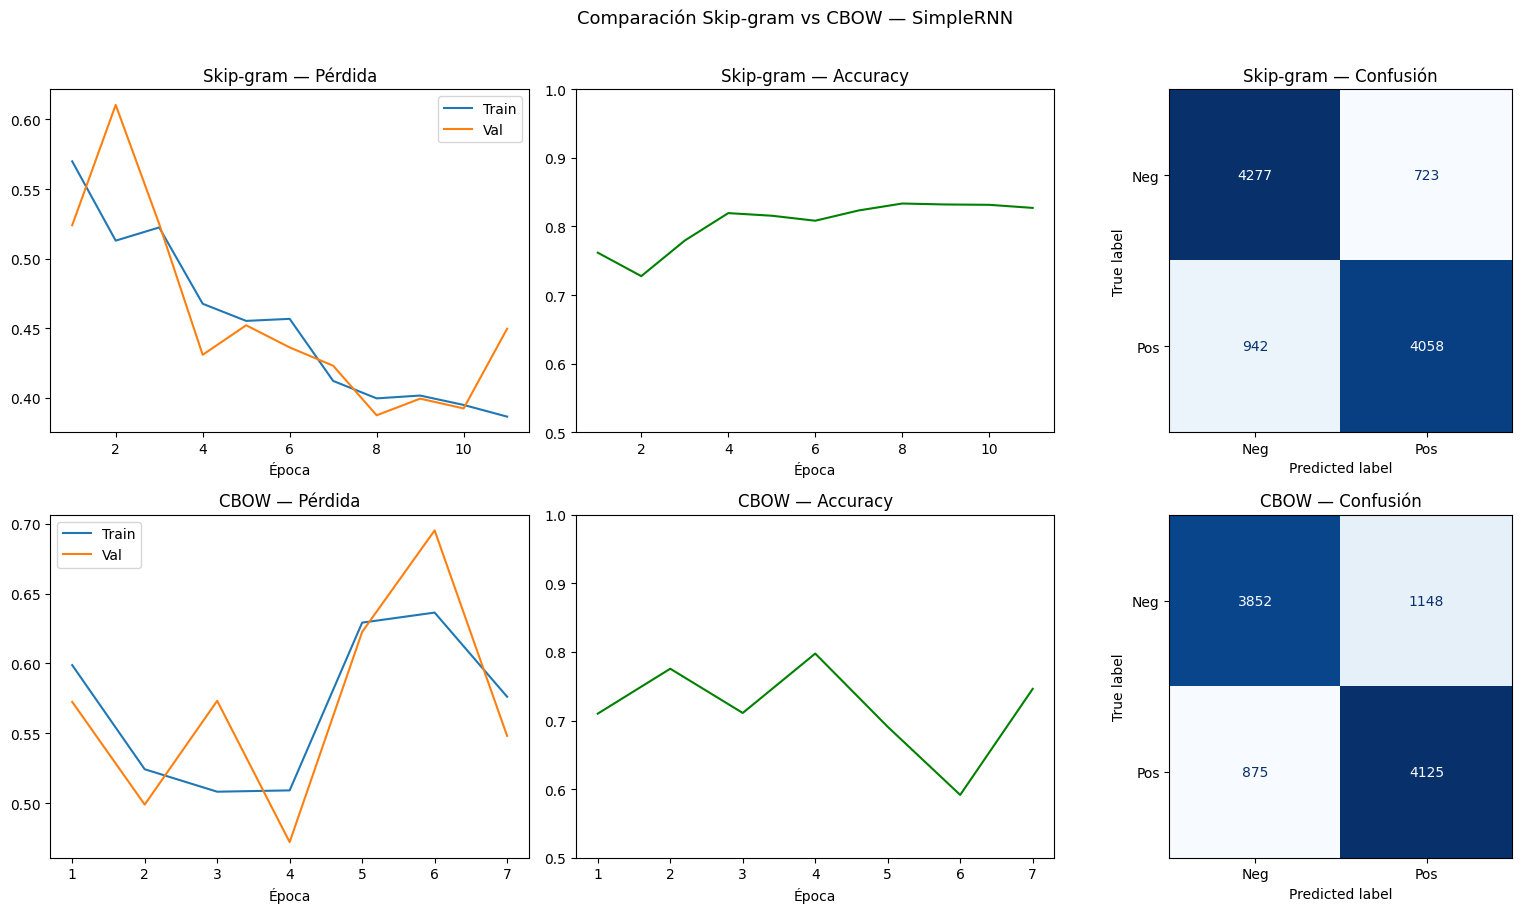

In [85]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
configs = [
    (history_sg,   "Skip-gram", labels_sg,   preds_sg),
    (history_cbow, "CBOW",      labels_cbow, preds_cbow),
]

for row, (hist, name, labels, preds) in enumerate(configs):
    epochs = range(1, len(hist["train_loss"]) + 1)

    # Curva de pérdida
    axes[row, 0].plot(epochs, hist["train_loss"], label="Train")
    axes[row, 0].plot(epochs, hist["val_loss"],   label="Val")
    axes[row, 0].set_title(f"{name} — Pérdida")
    axes[row, 0].set_xlabel("Época")
    axes[row, 0].legend()

    # Accuracy
    axes[row, 1].plot(epochs, hist["val_acc"], color="green")
    axes[row, 1].set_title(f"{name} — Accuracy")
    axes[row, 1].set_xlabel("Época")
    axes[row, 1].set_ylim(0.5, 1.0)

    # Matriz de confusión
    ConfusionMatrixDisplay.from_predictions(
        labels, preds,
        display_labels=["Neg", "Pos"],
        cmap="Blues",
        ax=axes[row, 2],
        colorbar=False
    )
    axes[row, 2].set_title(f"{name} — Confusión")

plt.suptitle("Comparación Skip-gram vs CBOW — SimpleRNN", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

En términos comparativos, Skip-gram superó a CBOW en 3 puntos de accuracy, 5 puntos de ROC-AUC y mostró un entrenamiento significativamente más estable. Esto puede atribuirse a que Skip-gram, al predecir el contexto a partir de una palabra central, genera representaciones más ricas para palabras individuales con mayor carga semántica, lo cual favorece tareas donde el sentimiento está concentrado en términos específicos como adjetivos y adverbios. CBOW por su parte promedia el contexto para predecir la palabra central, produciendo embeddings más suavizados que pueden perder matices semánticos relevantes para el análisis de sentimiento. Ambos modelos demuestran que embeddings preentrenados de alta dimensión aportan una base semántica sólida incluso para arquitecturas recurrentes simples, aunque una LSTM o GRU probablemente mitigaría la inestabilidad observada en CBOW al manejar mejor las dependencias de largo plazo.

La SimpleRNN es arquitectónicamente propensa a olvidar información de largo plazo debido al problema del gradiente desvaneciente, lo que la hace dependiente de que los embeddings de entrada ya contengan suficiente información semántica para compensar esa debilidad, razón por la cual la calidad del embedding impacta directamente en la estabilidad y el rendimiento del entrenamiento, como quedó evidenciado con CBOW. En ese sentido, esta arquitectura funciona mejor como línea base que como solución definitiva: establece un piso de rendimiento sólido y permite comparar el aporte de distintos esquemas de representación

## Red GRU (Gated Recurrent Unit)

Introducida por Kyunghyun Cho et al. en 2014, la GRU aborda el problema del gradiente desvanecido que enfrentan las RNNs tradicionales.

La arquitectura GRU incluye dos puertas primarias: **la puerta de actualización y la puerta de reinicio**, estas puertas ayudan al modelo a decidir qué información retener y cuál descartar en cada paso temporal. [4]

### Puerta de actualización: 
Es responsable de decidir qué información pasada de $h_{t-1}$ es útil para el cálculo actual y el futuro, es básicamente la misma ecuación que una celda recurrente regular, pero la diferencia está en lo que aprenden las matrices de pesos: aprenderán qué recordar. [5]

### Puerta de reinicio:
Decide cuánta información pasada olvidar, cuando se activa, permite que la celda ignore partes de los datos pasados, lo que ayuda a concentrarse en información nueva y relevante. [5]


### Definición del modelo GRU

Este código define una red neuronal llamada `SentimentGRU` la cual recibe oraciones convertidas en números (300 valores por palabra como se ve en el código anterior) y predice si su sentimiento es positivo o negativo. 

* Primero empaqueta las oraciones para que la GRU ignore los rellenos de ceros que se agregan para igualar longitudes

* Luego la GRU lee cada oración palabra por palabra y construye un resumen interno de todo lo que leyó.

* Después se aplica Dropout para evitar que el modelo simplemente memorice los datos de entrenamiento.

* Finalmente una capa lineal convierte ese resumen en un único número que representa el sentimiento del texto.

In [92]:
class SentimentGRU(nn.Module):
    def __init__(self, input_size=300, hidden_size=HIDDEN_SIZE, dropout=0.3):
        super().__init__()
        self.gru  = nn.GRU(input_size, hidden_size, num_layers=1,
                           batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x, lengths):
        packed      = pack_padded_sequence(x, lengths.cpu(), batch_first=True,
                                           enforce_sorted=False)
        _, h_n      = self.gru(packed)
        h           = h_n.squeeze(0)
        return self.fc(self.drop(h)).squeeze(1)

### Función de entrenamiento para GRU

Esta función se encarga de todo el proceso de entrenamiento del modelo GRU de inicio a fin. 

* Primero prepara los datos de entrenamiento y prueba en lotes para que el modelo pueda procesarlos de a grupos en lugar de oración por oración. 

* Luego configura tres herramientas clave: la función de pérdida `BCEWithLogitsLoss` que mide qué tan equivocadas son las predicciones, el optimizador Adam que ajusta los pesos del modelo para mejorar, y un scheduler que reduce automáticamente la velocidad de aprendizaje cuando el modelo deja de mejorar. 

* En cada época el modelo primero entrena pasando por todos los datos de entrenamiento, calcula el error, propaga ese error hacia atrás con `loss.backward()` y ajusta sus pesos, con un límite al tamaño del gradiente (`clip_grad_norm_`) para evitar que los ajustes sean muy bruscos. 

* Después evalúa qué tan bien le va con los datos de prueba, calculando tanto la pérdida como la precisión convirtiendo los números de salida en predicciones binarias con un umbral de 0.5. 

* Finalmente, si la pérdida de validación no mejora durante varias épocas seguidas, el Early Stopping detiene el entrenamiento anticipadamente para no desperdiciar tiempo ni sobreajustar el modelo, y restaura los pesos de la mejor época encontrada.

In [ ]:
def train_model_gru(embedding_col, model_name, patience=3):
    print(f"\n{'='*55}")
    print(f"  Entrenando GRU con: {model_name}")
    print(f"{'='*55}")

    train_ds = IMDBDataset(train_df[embedding_col].tolist(), train_df["label"])
    test_ds  = IMDBDataset(test_df[embedding_col].tolist(),  test_df["label"])
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              collate_fn=collate_fn, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              collate_fn=collate_fn, num_workers=0, pin_memory=True)

    model     = SentimentGRU().to(DEVICE)  
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, factor=0.5)
    es        = EarlyStopping(patience=patience)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0
        for X, y, lengths in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X, lengths), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        avg_train = total_loss / len(train_loader)

        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for X, y, lengths in test_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                logits = model(X, lengths)
                val_loss += criterion(logits, y).item()
                preds     = (torch.sigmoid(logits) >= 0.5).long()
                correct  += (preds == y.long()).sum().item()
                total    += y.size(0)

        avg_val = val_loss / len(test_loader)
        val_acc = correct / total
        scheduler.step(avg_val)
        es.step(avg_val, model)

        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        history["val_acc"].append(val_acc)

        stop_mark = " ← mejor" if es.counter == 0 else f" (sin mejora: {es.counter}/{patience})"
        print(f"Epoch {epoch:>2}/{EPOCHS} | "
              f"Train: {avg_train:.4f} | Val: {avg_val:.4f} | "
              f"Acc: {val_acc:.4f}{stop_mark}")

        if es.stopped:
            print(f"\n⏹ Early stopping en época {epoch}. "
                  f"Mejor val_loss: {es.best_loss:.4f}")
            break

    es.restore(model)
    print("✔ Pesos restaurados a la mejor época.")
    return model, history, test_loader

### Entrenamiento de GRU con ambos Embeddings (Skip-Gram y CBOW)

Aquí se ejecuta el entrenamiento del modelo GRU dos veces, el primer modelo usa Skip-gram, que es un método de Word2Vec entrenado en noticias de Google con vectores de 300 dimensiones, cuya lógica es aprender a predecir las palabras del contexto a partir de una palabra central y el segundo modelo usa CBOW (Continuous Bag of Words) de FastText entrenado en noticias de Wikipedia, que hace lo contrario: predice una palabra central a partir de su contexto. 

La idea de correr ambos es comparar cuál representación de palabras le da mejores resultados a la GRU para el análisis de sentimientos, guardando por separado el modelo entrenado, el historial de métricas y el loader de datos de cada uno para poder analizarlos después.

In [94]:
model_gru_sg,   history_gru_sg,   loader_gru_sg   = train_model_gru("skipgram_embeddings", "Skip-gram (word2vec-google-news-300)")
model_gru_cbow, history_gru_cbow, loader_gru_cbow = train_model_gru("cbow_embeddings",     "CBOW (fasttext-wiki-news-subwords-300)")


  Entrenando GRU con: Skip-gram (word2vec-google-news-300)


c:\Users\desar\OneDrive\Escritorio\ai-notebooks\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  1/20 | Train: 0.3855 | Val: 0.3108 | Acc: 0.8633 ← mejor
Epoch  2/20 | Train: 0.2916 | Val: 0.2728 | Acc: 0.8831 ← mejor
Epoch  3/20 | Train: 0.2633 | Val: 0.2673 | Acc: 0.8871 ← mejor
Epoch  4/20 | Train: 0.2418 | Val: 0.2605 | Acc: 0.8919 ← mejor
Epoch  5/20 | Train: 0.2180 | Val: 0.2559 | Acc: 0.8927 ← mejor
Epoch  6/20 | Train: 0.1964 | Val: 0.2669 | Acc: 0.8926 (sin mejora: 1/3)
Epoch  7/20 | Train: 0.1709 | Val: 0.2703 | Acc: 0.8936 (sin mejora: 2/3)
Epoch  8/20 | Train: 0.1278 | Val: 0.3199 | Acc: 0.8934 (sin mejora: 3/3)

⏹ Early stopping en época 8. Mejor val_loss: 0.2559
✔ Pesos restaurados a la mejor época.

  Entrenando GRU con: CBOW (fasttext-wiki-news-subwords-300)
Epoch  1/20 | Train: 0.4562 | Val: 0.3628 | Acc: 0.8447 ← mejor
Epoch  2/20 | Train: 0.3297 | Val: 0.3145 | Acc: 0.8648 ← mejor
Epoch  3/20 | Train: 0.3113 | Val: 0.3197 | Acc: 0.8611 (sin mejora: 1/3)
Epoch  4/20 | Train: 0.2925 | Val: 0.2942 | Acc: 0.8750 ← mejor
Epoch  5/20 | Train: 0.2786 | Val: 0.28

* El modelo con Skip-gram aprendió más rápido y mejor, desde la primera época ya tenía una precisión del 86% y fue mejorando hasta llegar a un 89.27% en la época 5, en ese momento la pérdida de validación llegó su mínimo de 0.2559, y a partir de ahí, el modelo empezó a sobreajustarse, la pérdida de validación subió aunque la precisión seguía creciendo, y el Early Stopping lo detuvo en la época 8 restaurando los pesos de la época 5.

* El modelo con CBOW empezó más lento y menos estable, empezando en un 84% de precisión con una  caída en la época 3. Este necesitó más épocas para encontrar la mejor puntuación la cual fue en la época 6 con una pérdida de 0.2781 y un 88.12% de accuracy. Este también mostró más inestabilidad durante el entrenamiento, sugiriendo que los embeddings de FastText CBOW capturan el sentimiento de las reseñas con menos efectividad.

### Evaluación

La función `evaluate_model` recibe el modelo y su loader correspondiente, los pasa por el conjunto de prueba sin actualizar ningún peso (solo predice), y de ahí devuelve tres cosas por modelo: las etiquetas reales de cada reseña, las predicciones binarias que hizo el modelo (positivo o negativo), y las probabilidades exactas que asignó antes de redondear a 0 o 1. G

In [95]:
labels_gru_sg,   preds_gru_sg,   probs_gru_sg   = evaluate_model(model_gru_sg,   loader_gru_sg,   "GRU Skip-gram")
labels_gru_cbow, preds_gru_cbow, probs_gru_cbow = evaluate_model(model_gru_cbow, loader_gru_cbow, "GRU CBOW")


─────────────────────────────────────────────
  Resultados — GRU Skip-gram
─────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.91      0.87      0.89      5000
    Positive       0.88      0.91      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

ROC-AUC : 0.9612


c:\Users\desar\OneDrive\Escritorio\ai-notebooks\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



─────────────────────────────────────────────
  Resultados — GRU CBOW
─────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      5000
    Positive       0.88      0.88      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

ROC-AUC : 0.9530


Los resultados muestran que Skip-gram funcionó mejor que CBOW, logrando un 89% de precisión contra un 88%, y un ROC-AUC de 0.9612 contra 0.9530, indicando que Skip-gram acertó más y también tiene más confianza en sus predicciones. 

### Aprendizaje

Este código genera un esquema de 6 gráficas, 3 por cada modelo, para poder visualizar cómo aprendió cada uno. 

* La primera columna muestra las curvas de pérdida de entrenamiento y validación a lo largo de las épocas, lo que permite ver en qué momento el modelo dejó de mejorar o empezó a sobreajustarse. 

* La segunda columna muestra cómo va subiendo la precisión época a época, con el eje vertical limitado entre 0.5 y 1.0 para que las diferencias se vean más claramente. 

* La tercera columna muestra la matriz de confusión, la cual indica cuántas reseñas positivas y negativas el modelo clasificó correctamente y cuántas confundió entre sí.

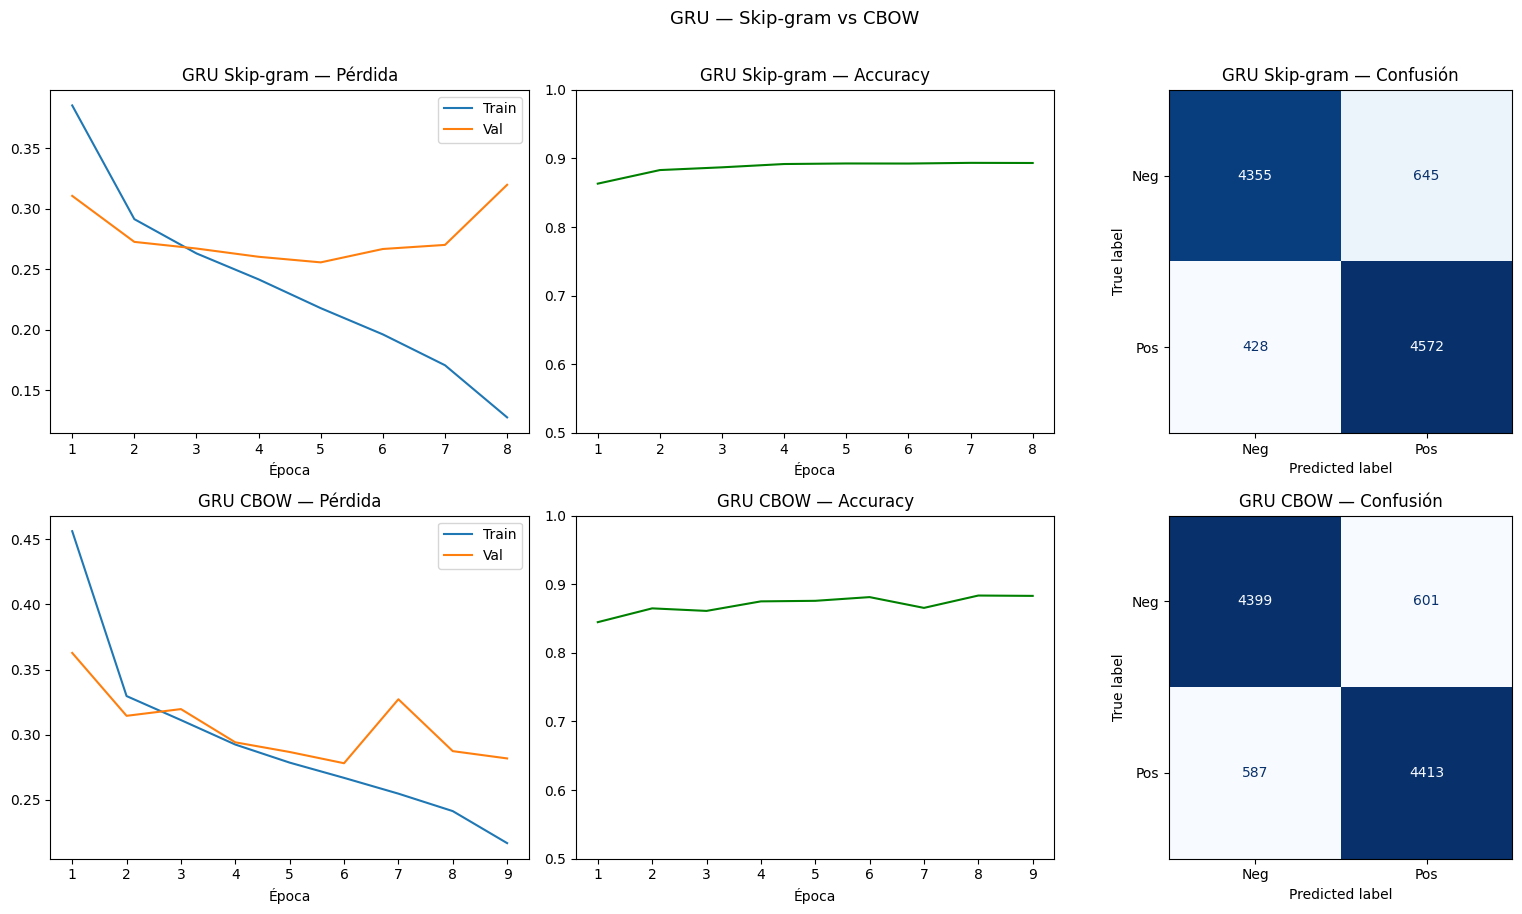

In [96]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
configs = [
    (history_gru_sg,   "GRU Skip-gram", labels_gru_sg,   preds_gru_sg),
    (history_gru_cbow, "GRU CBOW",      labels_gru_cbow, preds_gru_cbow),
]

for row, (hist, name, labels, preds) in enumerate(configs):
    epochs = range(1, len(hist["train_loss"]) + 1)

    axes[row, 0].plot(epochs, hist["train_loss"], label="Train")
    axes[row, 0].plot(epochs, hist["val_loss"],   label="Val")
    axes[row, 0].set_title(f"{name} — Pérdida")
    axes[row, 0].set_xlabel("Época")
    axes[row, 0].legend()

    axes[row, 1].plot(epochs, hist["val_acc"], color="green")
    axes[row, 1].set_title(f"{name} — Accuracy")
    axes[row, 1].set_xlabel("Época")
    axes[row, 1].set_ylim(0.5, 1.0)

    ConfusionMatrixDisplay.from_predictions(
        labels, preds,
        display_labels=["Neg", "Pos"],
        cmap="Blues", ax=axes[row, 2], colorbar=False
    )
    axes[row, 2].set_title(f"{name} — Confusión")

plt.suptitle("GRU — Skip-gram vs CBOW", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Como se puede observar en los resultados:
* Skip-gram aprendió de forma más estable, con la pérdida bajando constantemente hasta que el sobreajuste lo detuvo en la época 8. 

* CBOW se equivocó más, con varios irregularidades en la curva de validación mostrando un  aprendizaje menos seguro. 

* En las matrices de confusión se ve que Skip-gram es mejor detectando reseñas positivas (428 errores vs 587 de CBOW), mientras que en las negativas la diferencia es menor, lo que explica la ventaja de Skip-gram en el resultado final.

## Red LSTM (Long Short-Term Memory)

La LSTM extiende la RNN simple añadiendo una **celda de memoria** ($c_t$) separada del estado oculto ($h_t$)

A diferencia de la GRU, la LSTM mantiene **dos estados separados**: $c_t$ actúa como memoria de largo plazo y $h_t$ como representación de corto plazo. Esto le da más capacidad expresiva, aunque más parámetros que la GRU.

El objetivo de la memoria a largo plazo es atacar el problema del gradiente desvanecente donde en secuencias largas las aportaciones de los instantes de la secuencia mas lejanos al final de la misma son poco relevantes para el calulo del gradiente que se traduce en un "olvido" de la primera parte de la secuencia.

### Definición del modelo LSTM

In [97]:
class SentimentLSTM(nn.Module):
    def __init__(self, input_size=300, hidden_size=HIDDEN_SIZE, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1,
                            batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x, lengths):
        packed      = pack_padded_sequence(x, lengths.cpu(), batch_first=True,
                                           enforce_sorted=False)
        # La LSTM devuelve (output, (h_n, c_n)) — usamos solo h_n
        _, (h_n, _) = self.lstm(packed)
        h           = h_n.squeeze(0)
        return self.fc(self.drop(h)).squeeze(1)

### Función de entrenamiento para LSTM

In [98]:
def train_model_lstm(embedding_col, model_name, patience=3):
    print(f"\n{'='*55}")
    print(f"  Entrenando LSTM con: {model_name}")
    print(f"{'='*55}")

    train_ds = IMDBDataset(train_df[embedding_col].tolist(), train_df["label"])
    test_ds  = IMDBDataset(test_df[embedding_col].tolist(),  test_df["label"])
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              collate_fn=collate_fn, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              collate_fn=collate_fn, num_workers=0, pin_memory=True)

    model     = SentimentLSTM().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, factor=0.5)
    es        = EarlyStopping(patience=patience)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0
        for X, y, lengths in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X, lengths), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        avg_train = total_loss / len(train_loader)

        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for X, y, lengths in test_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                logits = model(X, lengths)
                val_loss += criterion(logits, y).item()
                preds     = (torch.sigmoid(logits) >= 0.5).long()
                correct  += (preds == y.long()).sum().item()
                total    += y.size(0)

        avg_val = val_loss / len(test_loader)
        val_acc = correct / total
        scheduler.step(avg_val)
        es.step(avg_val, model)

        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        history["val_acc"].append(val_acc)

        stop_mark = " ← mejor" if es.counter == 0 else f" (sin mejora: {es.counter}/{patience})"
        print(f"Epoch {epoch:>2}/{EPOCHS} | "
              f"Train: {avg_train:.4f} | Val: {avg_val:.4f} | "
              f"Acc: {val_acc:.4f}{stop_mark}")

        if es.stopped:
            print(f"\n⏹ Early stopping en época {epoch}. "
                  f"Mejor val_loss: {es.best_loss:.4f}")
            break

    es.restore(model)
    print("✔ Pesos restaurados a la mejor época.")
    return model, history, test_loader

### Entrenamiento de LSTM con ambos Embeddings (Skip-Gram y CBOW)

In [99]:
model_lstm_sg,   history_lstm_sg,   loader_lstm_sg   = train_model_lstm("skipgram_embeddings", "Skip-gram (word2vec-google-news-300)")
model_lstm_cbow, history_lstm_cbow, loader_lstm_cbow = train_model_lstm("cbow_embeddings",     "CBOW (fasttext-wiki-news-subwords-300)")


  Entrenando LSTM con: Skip-gram (word2vec-google-news-300)


c:\Users\desar\OneDrive\Escritorio\ai-notebooks\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  1/20 | Train: 0.4880 | Val: 0.4000 | Acc: 0.8348 ← mejor
Epoch  2/20 | Train: 0.3609 | Val: 0.3406 | Acc: 0.8445 ← mejor
Epoch  3/20 | Train: 0.3057 | Val: 0.2910 | Acc: 0.8794 ← mejor
Epoch  4/20 | Train: 0.2782 | Val: 0.2947 | Acc: 0.8815 (sin mejora: 1/3)
Epoch  5/20 | Train: 0.2588 | Val: 0.2730 | Acc: 0.8896 ← mejor
Epoch  6/20 | Train: 0.2394 | Val: 0.2770 | Acc: 0.8877 (sin mejora: 1/3)
Epoch  7/20 | Train: 0.2221 | Val: 0.2690 | Acc: 0.8899 ← mejor
Epoch  8/20 | Train: 0.2054 | Val: 0.2740 | Acc: 0.8920 (sin mejora: 1/3)
Epoch  9/20 | Train: 0.1882 | Val: 0.2880 | Acc: 0.8871 (sin mejora: 2/3)
Epoch 10/20 | Train: 0.1547 | Val: 0.2959 | Acc: 0.8913 (sin mejora: 3/3)

⏹ Early stopping en época 10. Mejor val_loss: 0.2690
✔ Pesos restaurados a la mejor época.

  Entrenando LSTM con: CBOW (fasttext-wiki-news-subwords-300)
Epoch  1/20 | Train: 0.5562 | Val: 0.4329 | Acc: 0.8115 ← mejor
Epoch  2/20 | Train: 0.4462 | Val: 0.3906 | Acc: 0.8306 ← mejor
Epoch  3/20 | Train: 0.3819

### Evaluación

In [100]:
labels_lstm_sg,   preds_lstm_sg,   probs_lstm_sg   = evaluate_model(model_lstm_sg,   loader_lstm_sg,   "LSTM Skip-gram")
labels_lstm_cbow, preds_lstm_cbow, probs_lstm_cbow = evaluate_model(model_lstm_cbow, loader_lstm_cbow, "LSTM CBOW")


─────────────────────────────────────────────
  Resultados — LSTM Skip-gram
─────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89      5000
    Positive       0.89      0.89      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

ROC-AUC : 0.9569


c:\Users\desar\OneDrive\Escritorio\ai-notebooks\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



─────────────────────────────────────────────
  Resultados — LSTM CBOW
─────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.87      0.88      0.88      5000
    Positive       0.88      0.87      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

ROC-AUC : 0.9499


### Curvas de aprendizaje y matrices de confusión

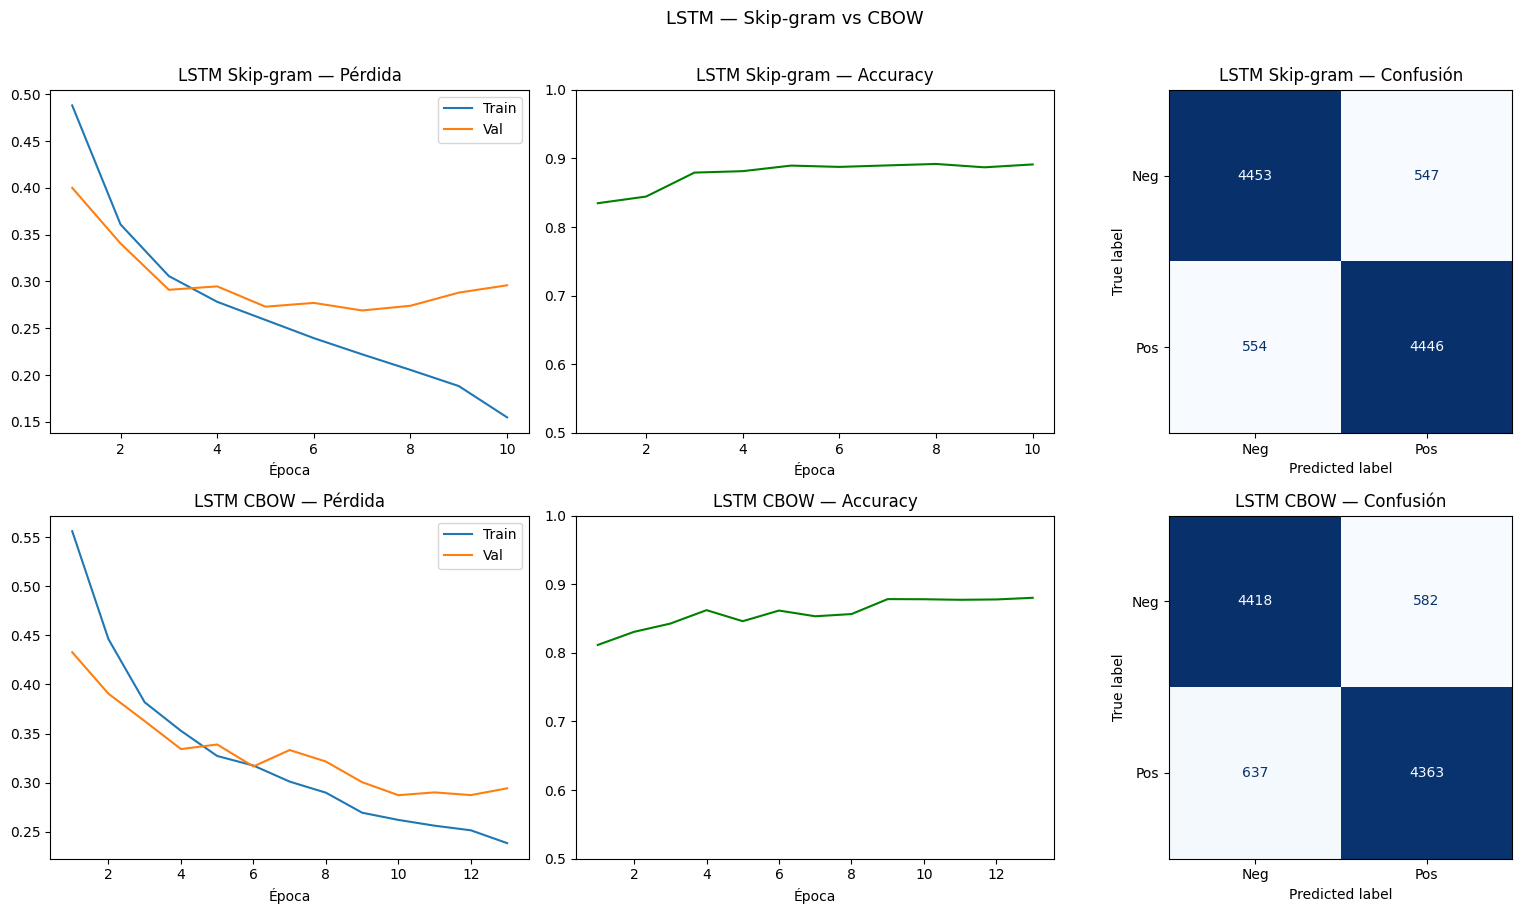

In [101]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
configs = [
    (history_lstm_sg,   "LSTM Skip-gram", labels_lstm_sg,   preds_lstm_sg),
    (history_lstm_cbow, "LSTM CBOW",      labels_lstm_cbow, preds_lstm_cbow),
]

for row, (hist, name, labels, preds) in enumerate(configs):
    epochs = range(1, len(hist["train_loss"]) + 1)

    axes[row, 0].plot(epochs, hist["train_loss"], label="Train")
    axes[row, 0].plot(epochs, hist["val_loss"],   label="Val")
    axes[row, 0].set_title(f"{name} — Pérdida")
    axes[row, 0].set_xlabel("Época")
    axes[row, 0].legend()

    axes[row, 1].plot(epochs, hist["val_acc"], color="green")
    axes[row, 1].set_title(f"{name} — Accuracy")
    axes[row, 1].set_xlabel("Época")
    axes[row, 1].set_ylim(0.5, 1.0)

    ConfusionMatrixDisplay.from_predictions(
        labels, preds,
        display_labels=["Neg", "Pos"],
        cmap="Blues", ax=axes[row, 2], colorbar=False
    )
    axes[row, 2].set_title(f"{name} — Confusión")

plt.suptitle("LSTM — Skip-gram vs CBOW", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Análisis Comparativo Final: RNN vs GRU vs LSTM

En esta sección consolidamos los resultados de los seis modelos entrenados:

| Configuración | Arquitectura | Embedding |
|---|---|---|
| 1 | RNN | Skip-gram |
| 2 | RNN | CBOW |
| 3 | GRU | Skip-gram |
| 4 | GRU | CBOW |
| 5 | LSTM | Skip-gram |
| 6 | LSTM | CBOW |

In [102]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

all_configs = [
    ("RNN",  "Skip-gram", labels_sg,        preds_sg,        probs_sg),
    ("RNN",  "CBOW",      labels_cbow,       preds_cbow,      probs_cbow),
    ("GRU",  "Skip-gram", labels_gru_sg,     preds_gru_sg,    probs_gru_sg),
    ("GRU",  "CBOW",      labels_gru_cbow,   preds_gru_cbow,  probs_gru_cbow),
    ("LSTM", "Skip-gram", labels_lstm_sg,    preds_lstm_sg,   probs_lstm_sg),
    ("LSTM", "CBOW",      labels_lstm_cbow,  preds_lstm_cbow, probs_lstm_cbow),
]

rows = []
for arch, emb, labels, preds, probs in all_configs:
    rows.append({
        "Arquitectura": arch,
        "Embedding":    emb,
        "Accuracy":     round(accuracy_score(labels, preds), 4),
        "F1":           round(f1_score(labels, preds), 4),
        "ROC-AUC":      round(roc_auc_score(labels, probs), 4),
    })

df_results = pd.DataFrame(rows)
df_results.style \
    .background_gradient(subset=["Accuracy", "F1", "ROC-AUC"], cmap="YlGn") \
    .format({"Accuracy": "{:.4f}", "F1": "{:.4f}", "ROC-AUC": "{:.4f}"}) \
    .set_caption("Métricas comparativas — todos los modelos")

,Arquitectura,Embedding,Accuracy,F1,ROC-AUC
0,RNN,Skip-gram,0.8335,0.8298,0.9083
1,RNN,CBOW,0.7977,0.8031,0.8571
2,GRU,Skip-gram,0.8927,0.8950,0.9612
3,GRU,CBOW,0.8812,0.8814,0.9530
4,LSTM,Skip-gram,0.8899,0.8898,0.9569
5,LSTM,CBOW,0.8781,0.8774,0.9499


### Curvas de aprendizaje: Skip-gram (izquierda) vs CBOW (derecha)

Cada línea representa una arquitectura. La columna izquierda muestra el comportamiento con embeddings Skip-gram y la derecha con CBOW, lo que permite ver de un vistazo si una arquitectura se beneficia más de un tipo de embedding.

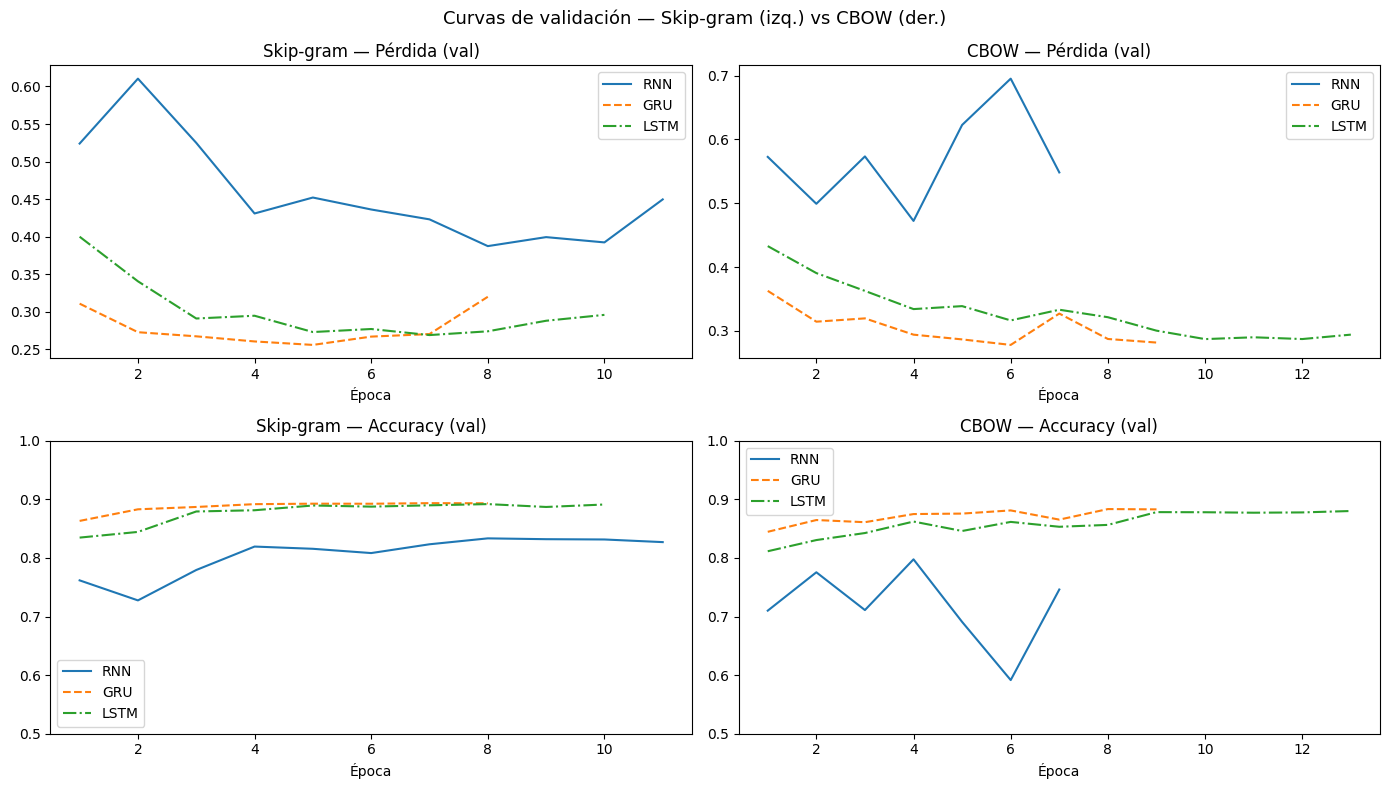

In [103]:
arch_styles = [
    (history_sg,       history_cbow,       "RNN",  "C0", "-"),
    (history_gru_sg,   history_gru_cbow,   "GRU",  "C1", "--"),
    (history_lstm_sg,  history_lstm_cbow,  "LSTM", "C2", "-."),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for hist_sg, hist_cbow, name, color, ls in arch_styles:
    e_sg   = range(1, len(hist_sg["val_loss"])   + 1)
    e_cbow = range(1, len(hist_cbow["val_loss"]) + 1)

    axes[0, 0].plot(e_sg,   hist_sg["val_loss"],   label=name, color=color, linestyle=ls)
    axes[0, 1].plot(e_cbow, hist_cbow["val_loss"],  label=name, color=color, linestyle=ls)
    axes[1, 0].plot(e_sg,   hist_sg["val_acc"],    label=name, color=color, linestyle=ls)
    axes[1, 1].plot(e_cbow, hist_cbow["val_acc"],   label=name, color=color, linestyle=ls)

titles = [
    ("Skip-gram — Pérdida (val)", "CBOW — Pérdida (val)"),
    ("Skip-gram — Accuracy (val)", "CBOW — Accuracy (val)"),
]
for row in range(2):
    for col in range(2):
        axes[row, col].set_title(titles[row][col])
        axes[row, col].set_xlabel("Época")
        axes[row, col].legend()

axes[1, 0].set_ylim(0.5, 1.0)
axes[1, 1].set_ylim(0.5, 1.0)

plt.suptitle("Curvas de validación — Skip-gram (izq.) vs CBOW (der.)", fontsize=13)
plt.tight_layout()
plt.show()

### Comparación de métricas finales: Skip-gram vs CBOW por arquitectura

Barras agrupadas: cada grupo es una arquitectura (RNN / GRU / LSTM). Dentro de cada grupo, la barra azul corresponde a Skip-gram y la naranja a CBOW.

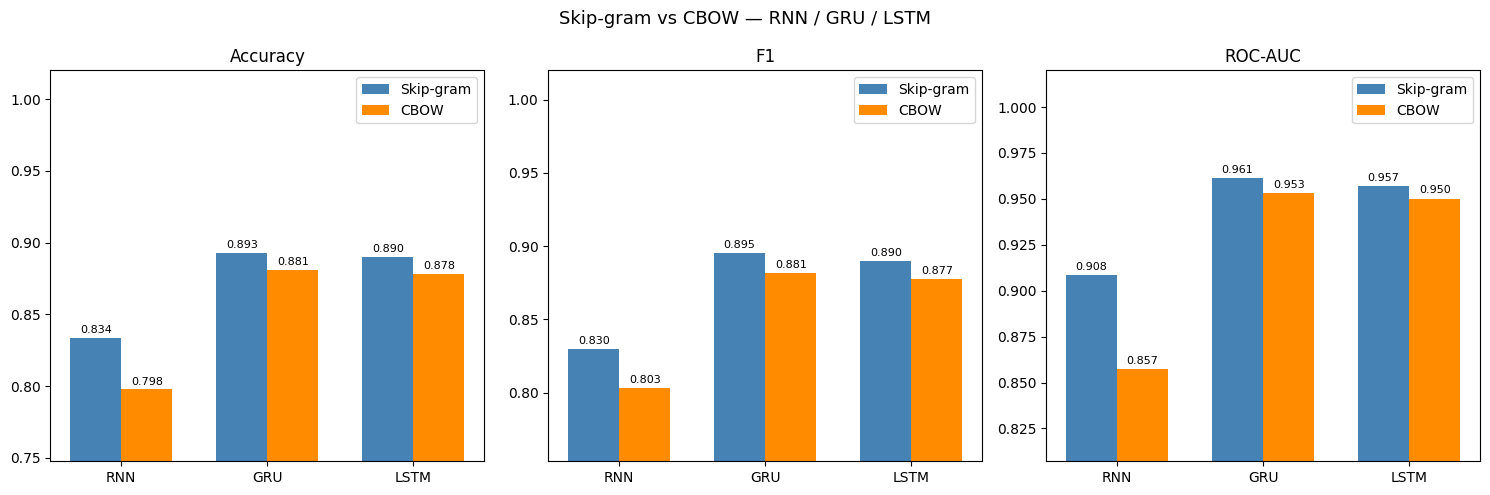

In [104]:
metrics  = ["Accuracy", "F1", "ROC-AUC"]
archs    = ["RNN", "GRU", "LSTM"]
x        = np.arange(len(archs))
width    = 0.35

df_sg   = df_results[df_results["Embedding"] == "Skip-gram"].set_index("Arquitectura")
df_cbow = df_results[df_results["Embedding"] == "CBOW"].set_index("Arquitectura")

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for i, metric in enumerate(metrics):
    sg_vals   = [df_sg.loc[a, metric]   for a in archs]
    cbow_vals = [df_cbow.loc[a, metric] for a in archs]

    axes[i].bar(x - width / 2, sg_vals,   width, label="Skip-gram", color="steelblue")
    axes[i].bar(x + width / 2, cbow_vals, width, label="CBOW",      color="darkorange")

    # Anotaciones de valor
    for j, (sg, cb) in enumerate(zip(sg_vals, cbow_vals)):
        axes[i].text(j - width / 2, sg   + 0.002, f"{sg:.3f}",   ha="center", va="bottom", fontsize=8)
        axes[i].text(j + width / 2, cb   + 0.002, f"{cb:.3f}",   ha="center", va="bottom", fontsize=8)

    axes[i].set_title(metric, fontsize=12)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(archs)
    min_val = min(sg_vals + cbow_vals)
    axes[i].set_ylim(max(0.5, min_val - 0.05), 1.02)
    axes[i].legend()

plt.suptitle("Skip-gram vs CBOW — RNN / GRU / LSTM", fontsize=13)
plt.tight_layout()
plt.show()

### Matrices de confusión comparativas

Grilla 2 × 3: **filas = tipo de embedding** (Skip-gram arriba, CBOW abajo), **columnas = arquitectura** (RNN | GRU | LSTM).  
Permite comparar cómo cada combinación clasifica positivos y negativos.

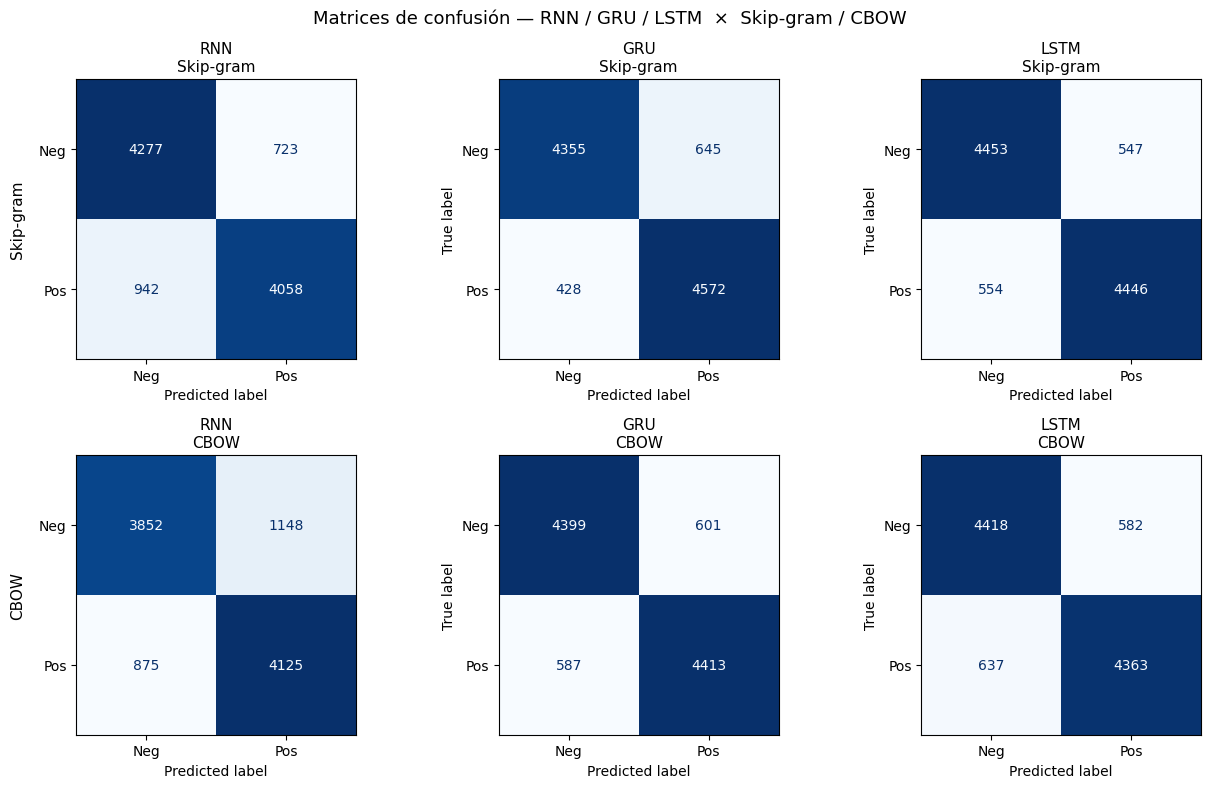

In [105]:
# Filas: Skip-gram (0), CBOW (1)
# Columnas: RNN (0), GRU (1), LSTM (2)
grid = [
    [("RNN\nSkip-gram",  labels_sg,       preds_sg),
     ("GRU\nSkip-gram",  labels_gru_sg,   preds_gru_sg),
     ("LSTM\nSkip-gram", labels_lstm_sg,  preds_lstm_sg)],
    [("RNN\nCBOW",       labels_cbow,     preds_cbow),
     ("GRU\nCBOW",       labels_gru_cbow, preds_gru_cbow),
     ("LSTM\nCBOW",      labels_lstm_cbow, preds_lstm_cbow)],
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for row_idx, row_configs in enumerate(grid):
    for col_idx, (title, labels, preds) in enumerate(row_configs):
        ax = axes[row_idx, col_idx]
        ConfusionMatrixDisplay.from_predictions(
            labels, preds,
            display_labels=["Neg", "Pos"],
            cmap="Blues",
            ax=ax,
            colorbar=False,
        )
        ax.set_title(title, fontsize=11)

# Etiquetas de fila en el eje y del primer panel
axes[0, 0].set_ylabel("Skip-gram", fontsize=11, labelpad=10)
axes[1, 0].set_ylabel("CBOW", fontsize=11, labelpad=10)

plt.suptitle("Matrices de confusión — RNN / GRU / LSTM  ×  Skip-gram / CBOW", fontsize=13)
plt.tight_layout()
plt.show()


## Análisis de Matrices de Confusión


**RNN simple**

- La RNN con Skip-gram comete menos FN que la versión CBOW. Esto puede deberse a que Skip-gram parte de la palabra hacia el contexto, siendo capaz de capturar el contexto que rodean las palabras que transmiten sentimientos positivos o negativos. 
- La RNN con CBOW muestra un número mayor de FN. CBOW al predecir a partir del contexto pede diluir la aportacion de palabras clave que transmitan el sentimiento lo que al juntarse con el desvanecimiento del gradiente hace que se degradade aún más en secuencias largas como las reviews.

**GRU**

- Ambas versiones (Skip-gram y CBOW) reducen los FN respecto a la RNN. Lo que es esperable debido al mecanismo de atencion de la arquitectura.
- La matriz de CBOW en GRU es apreciablemente más equilibrada que en RNN+CBOW donde los FN estaban disparados, probablemente el mecanismo de atención de la arquitectura compense el uso de CBOW.

**LSTM**

- La LSTM muestra matrices muy similares a la GRU, con leve ventaja en la versión Skip-gram. Las arquitecturas GRU y LSTM practicamnte convergen en los resultados, esto es esperable en cierta medida ya que los mecanismos de atención de ambas arquitecturas son similares y las reviews no son secuencias tan largas donde el mecanismo de memoria de largo plazo juegue un papel tan reelevante con respecto de la arquitectura GRU.

### Seleccion de modelo

| Criterio de selección | Modelo recomendado | Justificación |
|---|---|---|
| **Máximo rendimiento** | LSTM + Skip-gram | Mejor ROC-AUC y mejor distribucion de FN y FP |
| **Mejor rendimiento / velocidad de entrenamiento** | GRU + Skip-gram | menos parámetros que LSTM, resultados equivalentes |


## Referencias

[1] TensorFlow. (2024, julio 19). Word2Vec. TensorFlow Text Tutorials. https://www.tensorflow.org/text/tutorials/word2vec

[2] Google. (2013). *word2vec-google-news-300*. https://code.google.com/archive/p/word2vec/

[3] Facebook AI Research. (2018). English word vectors. fastText. https://fasttext.cc/docs/en/english-vectors.html

[4] Cho et al. (2014), paper original: arxiv.org/abs/1406.1078

[5] "The Math Behind GRUs", Towards Data Science: towardsdatascience.com/the-math-behind-gated-recurrent-units